# **Exploratory Data Analysis (EDA) Baru - Analisis Profil Nasabah & Kepemilikan Produk**

Notebook ini dibuat untuk melakukan **Exploratory Data Analysis (EDA)** baru dengan mengacu pada kode sebelumnya, menggunakan dataset yang telah melalui proses feature engineering (`clean_customer_dataNEW.csv`). 

Tujuan utama dari EDA ini adalah:
1. **Memahami Profil Demografis Nasabah** (Usia, Pendapatan, Credit Score, dll).
2. **Menganalisis Pola Kepemilikan Produk** dan korelasi antar produk perbankan utama.
3. **Menganalisis Hubungan Fitur Transaksi (SPS, TSI)** dengan perilaku nasabah.

---

## **1. Import Library & Load Dataset**

Langkah pertama adalah mengimpor library standard untuk analisis data (`pandas`, `numpy`) dan visualisasi (`matplotlib`, `seaborn`), kemudian memuat file CSV hasil feature engineering.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set style untuk plot yang lebih premium
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

In [ ]:
# Load dataset hasil feature engineering
dataset_path = "../data/processed/clean_customer_dataNEW.csv"
if os.path.exists(dataset_path):
    df = pd.read_csv(dataset_path)
    print(f"Dataset berhasil dimuat! Jumlah baris: {df.shape[0]}, Jumlah kolom: {df.shape[1]}")
else:
    print("File dataset tidak ditemukan. Pastikan path sudah benar.")

Dataset berhasil dimuat! Jumlah baris: 939470, Jumlah kolom: 35


## **2. Informasi Dasar & Pemeriksaan Dataset**

Mari kita lihat struktur kolom, tipe data, dan sampel data untuk memahami fitur apa saja yang tersedia.

In [3]:
# Menampilkan tipe data dan info non-null
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 939470 entries, 0 to 939469
Data columns (total 35 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   customer_id                    939470 non-null  int64  
 1   residence_country              939470 non-null  str    
 2   gender                         939470 non-null  int64  
 3   age                            939470 non-null  int64  
 4   first_join_date                939470 non-null  str    
 5   residence_index                939470 non-null  str    
 6   channel_entrace                939470 non-null  str    
 7   activity_status                939470 non-null  int64  
 8   household_gross_income         939470 non-null  float64
 9   saving_account                 939470 non-null  int64  
 10  guarantees                     939470 non-null  int64  
 11  junior_account                 939470 non-null  int64  
 12  loans                          939470 non

In [4]:
# Menampilkan 5 baris pertama dari dataset
df.head()

,customer_id,residence_country,gender,age,first_join_date,residence_index,channel_entrace,activity_status,household_gross_income,saving_account,...,avg_expense_days_per_month,expense_amount_cv,avg_transactions_per_month,monthly_transaction_std,total_transactions,active_months,avg_monthly_transaction_count,SPS,TSI,demographic_score
0,1375586,ES,0,35,2020-01-12,Y,KHL,1,50887.44,1,...,1.272727,0.939871,1.250000,0.452267,15.0,12.0,1.25,0.122553,0.485454,0.381798
1,1050611,ES,0,23,2017-08-10,Y,KHE,1,30619.38,1,...,1.285714,1.348381,1.357143,0.633324,19.0,14.0,1.36,0.090260,0.201175,0.168332
2,1050612,ES,1,23,2017-08-10,Y,KHE,1,57420.17,0,...,1.000000,0.732798,1.000000,0.000000,10.0,10.0,1.00,0.142588,0.633601,0.418683
3,1050613,ES,1,22,2017-08-10,Y,KHD,1,115661.59,0,...,1.266667,0.709893,1.312500,0.602080,21.0,16.0,1.31,0.103972,0.541213,0.428340
4,1050614,ES,0,23,2017-08-10,Y,KHE,1,28358.36,0,...,1.125000,0.871065,1.125000,0.353553,9.0,8.0,1.12,0.146832,0.539062,0.417684


## **3. Analisis Demografis Nasabah**

Bagian ini bertujuan untuk menganalisis distribusi karakteristik nasabah seperti:
- **Usia (Age)**: Mengetahui rentang usia nasabah perbankan.
- **Pendapatan Pribadi (Personal Income)** vs **Pendapatan Rumah Tangga (Household Gross Income)**.
- **Credit Score**: Menilai distribusi kelayakan kredit nasabah.

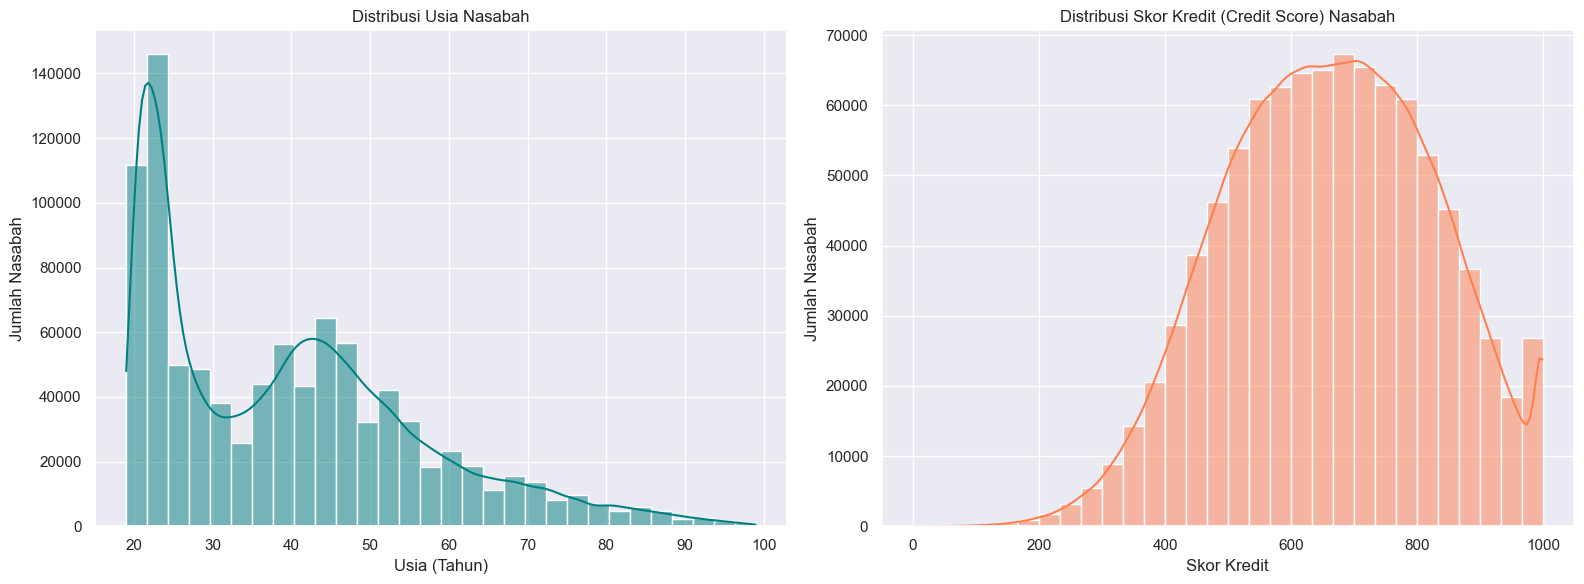

In [5]:
# Visualisasi Distribusi Usia (Age) & Credit Score
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram Usia
sns.histplot(data=df, x='age', kde=True, bins=30, ax=axes[0], color='teal')
axes[0].set_title('Distribusi Usia Nasabah')
axes[0].set_xlabel('Usia (Tahun)')
axes[0].set_ylabel('Jumlah Nasabah')

# Histogram Credit Score
sns.histplot(data=df, x='credit_score', kde=True, bins=30, ax=axes[1], color='coral')
axes[1].set_title('Distribusi Skor Kredit (Credit Score) Nasabah')
axes[1].set_xlabel('Skor Kredit')
axes[1].set_ylabel('Jumlah Nasabah')

plt.tight_layout()
plt.show()

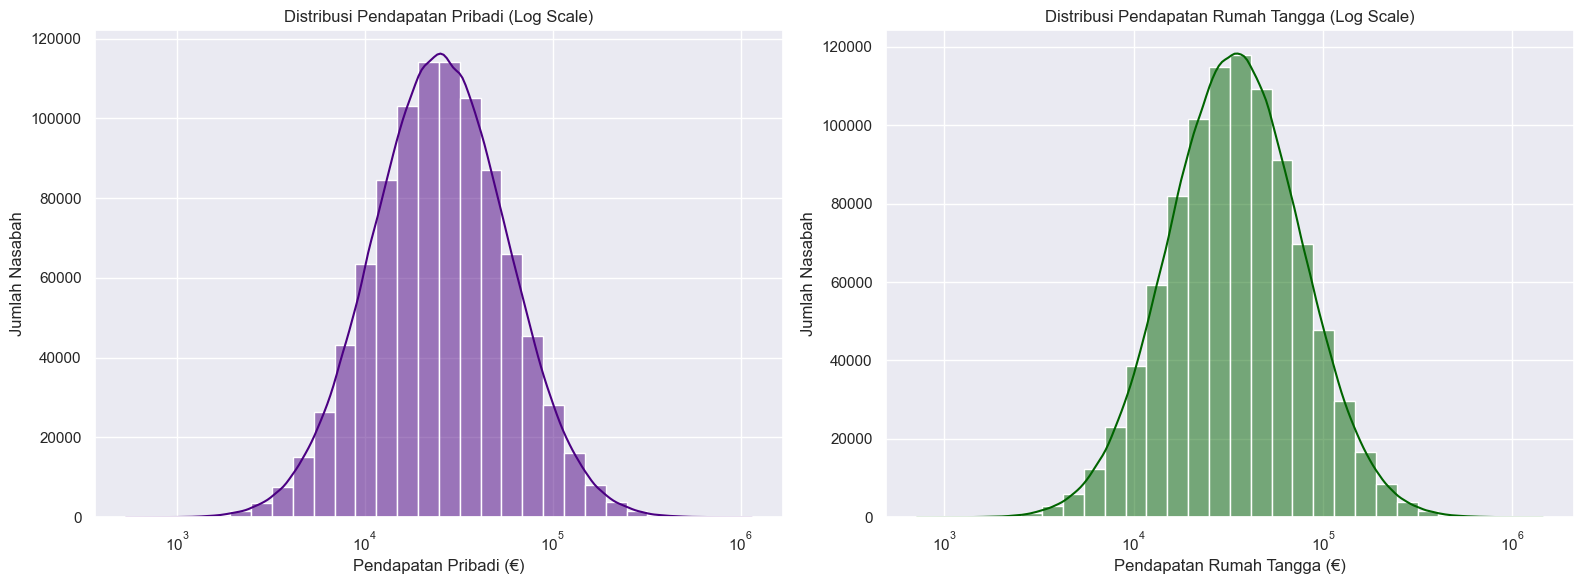

In [6]:
# Visualisasi Distribusi Pendapatan (Skala Logaritmik untuk mengatasi outlier tinggi)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pendapatan Pribadi
sns.histplot(data=df, x='personal_income', kde=True, bins=30, ax=axes[0], color='indigo', log_scale=True)
axes[0].set_title('Distribusi Pendapatan Pribadi (Log Scale)')
axes[0].set_xlabel('Pendapatan Pribadi (€)')
axes[0].set_ylabel('Jumlah Nasabah')

# Pendapatan Rumah Tangga
sns.histplot(data=df, x='household_gross_income', kde=True, bins=30, ax=axes[1], color='darkgreen', log_scale=True)
axes[1].set_title('Distribusi Pendapatan Rumah Tangga (Log Scale)')
axes[1].set_xlabel('Pendapatan Rumah Tangga (€)')
axes[1].set_ylabel('Jumlah Nasabah')

plt.tight_layout()
plt.show()

**Penjelasan Visualisasi Demografis:**
1. **Distribusi Usia**: Dapat mengidentifikasi kelompok usia dominan (misal: usia muda/universitas vs usia produktif mapan vs pensiunan). Hal ini membantu mendesain produk yang sesuai (seperti *junior account* atau produk pensiun).
2. **Credit Score**: Menunjukkan sebaran kelayakan kredit nasabah. Konsentrasi di skor tertentu membantu bank menentukan tingkat risiko portofolio pinjaman.
3. **Pendapatan (Skala Log)**: Karena sebaran pendapatan memiliki outlier sangat tinggi (nasabah ultra kaya), penggunaan skala logaritmik membantu visualisasi sebaran utama nasabah dengan lebih jelas.

## **4. Analisis Korelasi & Kepemilikan Produk**

Model machine learning kita memprediksi 5 produk utama (label):
- `saving_account`
- `guarantees`
- `junior_account`
- `loans`
- `pension`

Mari kita lihat seberapa banyak nasabah yang memiliki masing-masing produk dan bagaimana hubungan korelasi antar kepemilikan produk tersebut.

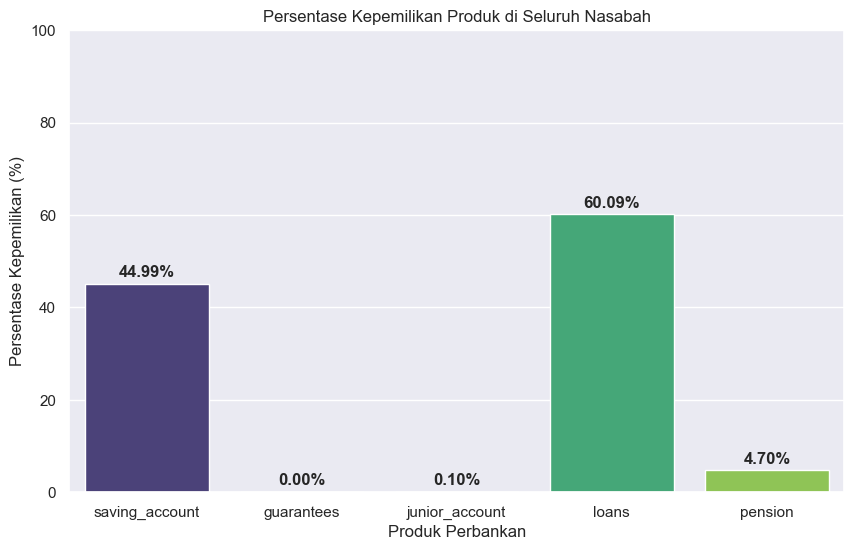

In [7]:
# Menghitung persentase kepemilikan produk
label_cols = ['saving_account', 'guarantees', 'junior_account', 'loans', 'pension']
ownership = df[label_cols].mean() * 100

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=ownership.index, y=ownership.values, hue=ownership.index, legend=False, palette='viridis')
plt.title('Persentase Kepemilikan Produk di Seluruh Nasabah')
plt.ylabel('Persentase Kepemilikan (%)')
plt.xlabel('Produk Perbankan')

# Menambahkan label angka di atas bar
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 1),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')

plt.ylim(0, 100)
plt.show()

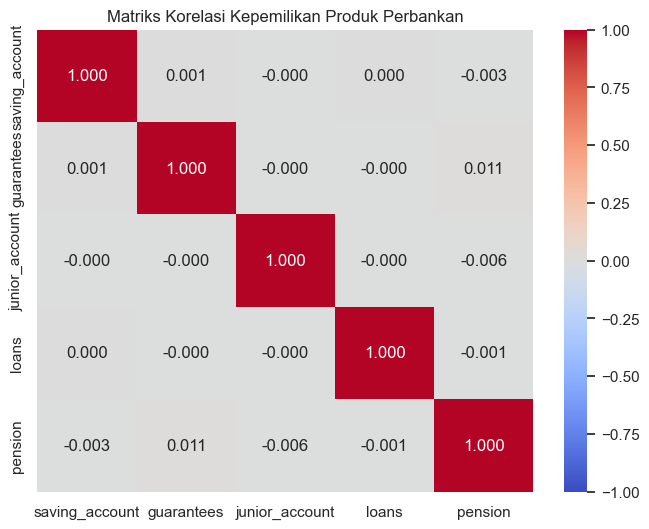

In [8]:
# Korelasi Matrix antar kepemilikan produk
corr = df[label_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.3f')
plt.title('Matriks Korelasi Kepemilikan Produk Perbankan')
plt.show()

**Penjelasan Visualisasi Produk:**
1. **Barplot Kepemilikan**: Menunjukkan penetrasi pasar setiap produk. Biasanya, tabungan (`saving_account`) memiliki penetrasi tertinggi, sedangkan produk penjaminan (`guarantees`) atau pinjaman (`loans`) memiliki tingkat kepemilikan yang lebih rendah.
2. **Matriks Korelasi Heatmap**: Menunjukkan korelasi linear antarlabeled produk. Korelasi positif tinggi (berwarna merah) menunjukkan produk yang sering dibeli bersamaan oleh nasabah (misalnya nasabah dengan akun pensiun juga sering memiliki akun tabungan tertentu). Korelasi negatif (berwarna biru) menunjukkan produk yang saling bertolak belakang (misalnya *junior_account* tidak pernah dimiliki bersamaan dengan produk *pension* karena segmentasi usia yang bertentangan).

## **5. Analisis Fitur Transaksi & Finansial (SPS, TSI, & Segmen)**

Fitur bentukan hasil feature engineering:
- **SPS (Spending Pattern Score)**: Rasio frekuensi transaksi pengeluaran terhadap total transaksi masukan + keluaran.
- **TSI (Transaction Stability Index)**: Stabilitas transaksi bulanan nasabah (diukur dari standar deviasi volume transaksi bulanan).
- **Customer Segment Model**: Kategori klasifikasi segmen nasabah (seperti TOP, PARTICULARES, atau UNIVERSITARIO).

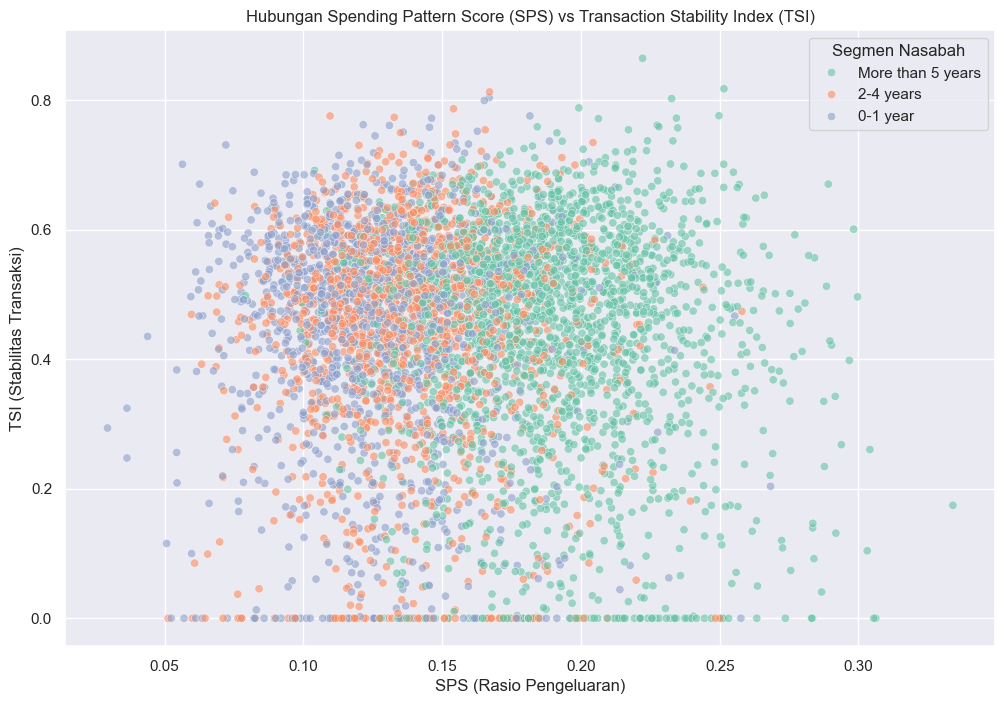

In [9]:
# Hubungan SPS dan TSI berdasarkan Segmen Nasabah
# Mengambil sampel data (misal 5000 baris) agar visualisasi scatterplot lebih ringan dan jelas
df_sample = df.sample(n=5000, random_state=42) if len(df) > 5000 else df

plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_sample, x='SPS', y='TSI', hue='customer_segment_model', alpha=0.6, palette='Set2')
plt.title('Hubungan Spending Pattern Score (SPS) vs Transaction Stability Index (TSI)')
plt.xlabel('SPS (Rasio Pengeluaran)')
plt.ylabel('TSI (Stabilitas Transaksi)')
plt.legend(title='Segmen Nasabah')
plt.show()

In [10]:
# Rata-rata Skor Kredit dan Pendapatan berdasarkan Segmen Nasabah
segment_summary = df.groupby('customer_segment_model')[['personal_income', 'credit_score']].mean().reset_index()
print("Rangkuman Rata-rata Finansial per Segmen:")
print(segment_summary)

Rangkuman Rata-rata Finansial per Segmen:
  customer_segment_model  personal_income  credit_score
0               0-1 year     35258.759762    645.044132
1              2-4 years     35293.735998    663.072696
2      More than 5 years     35299.760189    667.825133


C:\Users\user\AppData\Local\Temp\ipykernel_6992\2393528921.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='customer_segment_model', y='personal_income', palette='pastel')


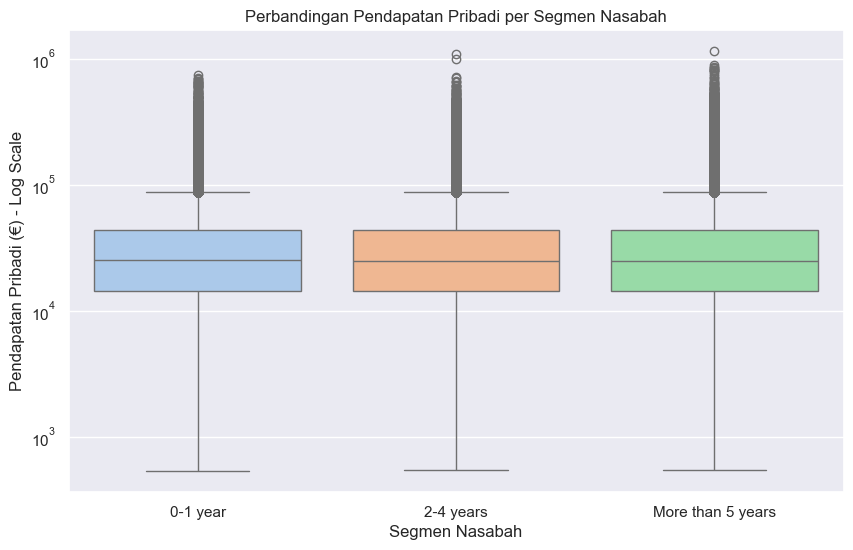

In [11]:
# Boxplot Pendapatan berdasarkan Segmen Nasabah
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='customer_segment_model', y='personal_income', palette='pastel')
plt.title('Perbandingan Pendapatan Pribadi per Segmen Nasabah')
plt.xlabel('Segmen Nasabah')
plt.ylabel('Pendapatan Pribadi (€) - Log Scale')
plt.yscale('log') # Menggunakan skala logaritmik karena outlier tinggi
plt.show()

**Penjelasan Analisis Perilaku Transaksi & Segmen:**
1. **Scatterplot SPS vs TSI**: Membantu memetakan nasabah secara perilaku. Nasabah di pojok kanan atas (SPS tinggi, TSI tinggi) memiliki pola pengeluaran aktif dengan frekuensi transaksi yang stabil setiap bulannya. Kita bisa melihat pengelompokan segmen nasabah (misalnya segmen TOP berkumpul di wilayah finansial tertentu).
2. **Rangkuman Finansial**: Menunjukkan nilai rata-rata tiap segmen. Ini membuktikan bahwa segmen `'01 - TOP'` memiliki pendapatan rata-rata yang jauh lebih tinggi dibanding `'03 - UNIVERSITARIO'` (nasabah mahasiswa).
3. **Boxplot Pendapatan (Log Scale)**: Memperlihatkan median, kuartil, dan variasi pendapatan di masing-masing segmen nasabah. Skala logaritmik membantu membandingkan bentuk distribusi secara utuh meskipun terdapat nasabah dengan pendapatan ekstrem.

## **Kesimpulan & Insight Rekomendasi Bisnis**

Berdasarkan analisis EDA di atas, berikut adalah insight penting yang dapat dipahami:
1. **Pemisahan Pasar**: Kelompok nasabah mahasiswa (`UNIVERSITARIO`) memiliki karakteristik usia muda, pendapatan rendah, dan skor kredit yang masih berkembang. Produk yang cocok adalah `junior_account`.
2. **Nasabah Bernilai Tinggi**: Segmen `TOP` memiliki tingkat pendapatan tinggi dan skor kredit stabil, menjadikannya target utama produk investasi (`pension`), kredit pemilikan rumah, atau kartu kredit premium.
3. **Korelasi Tabungan**: Akun tabungan (`saving_account`) adalah produk inti yang mendominasi kepemilikan nasabah. Segala promosi silang (*cross-selling*) sebaiknya dilakukan dengan memanfaatkan akun tabungan aktif sebagai basis dasar penawaran.